In [1]:
import json
import os
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')

project_data_path = '/content/drive/MyDrive/DSA210-Project/data/'

Mounted at /content/drive


In [2]:
with open(os.path.join(project_data_path, 'pokemon.json'), 'r', encoding='utf-8') as f:
    pokemon = json.load(f)

In [35]:
import pandas as pd
from scipy import stats

excluded_forms = ['-gmax']

bulk_array = []
off_gap_array = []

for name, details in pokemon.items():
    skip = False
    for keyword in excluded_forms:
      if(keyword in name):
        skip = True
        break
    if(not skip):
      stats_dict = {s['stat']['name']: s['base_stat'] for s in details['stats']}

      # Calculate BST
      bst = sum(stats_dict.values())

      # Calculate Bulk Metric
      # Bulk = (HP + Defense + Sp. Defense) / BST
      bulk = (stats_dict['hp'] + stats_dict['defense'] + stats_dict['special-defense']) / bst

      types = [t['type']['name'] for t in details['types']]
      is_water = 'water' in types

      bulk_array.append({'name': name, 'bulk': bulk, 'is_water': is_water})

      # Calculate Offensive Gap Metric
      # Offensive Gap = absolute_value(Attack - Special Attack)
      off_gap = abs(stats_dict['attack'] - stats_dict['special-attack'])

      if(details['generation'] < 4):
        pre_gen4 = True
      else:
        pre_gen4 = False

      off_gap_array.append({'name': name, 'off_gap': off_gap, 'pre_gen4': pre_gen4})


df_bulk = pd.DataFrame(bulk_array)
df_off_gap = pd.DataFrame(off_gap_array)
print(df_off_gap)

                      name  off_gap  pre_gen4
0                bulbasaur       16      True
1                  ivysaur       18      True
2                 venusaur       18      True
3               charmander        8      True
4               charmeleon       16      True
...                    ...      ...       ...
1242          zeraora-mega       10     False
1243       scovillain-mega        0     False
1244         glimmora-mega       60     False
1245  tatsugiri-curly-mega       70     False
1246       baxcalibur-mega       70     False

[1247 rows x 3 columns]


Hypothesis: Water type Pokémon are bulkier on average then other types
Bulk here is defined as the sum of the HP, Defense and Special Defense stats divided by the base stat total. Essentialy bulk is the percentage of a Pokémon base stats that are allocated for defensive stats.

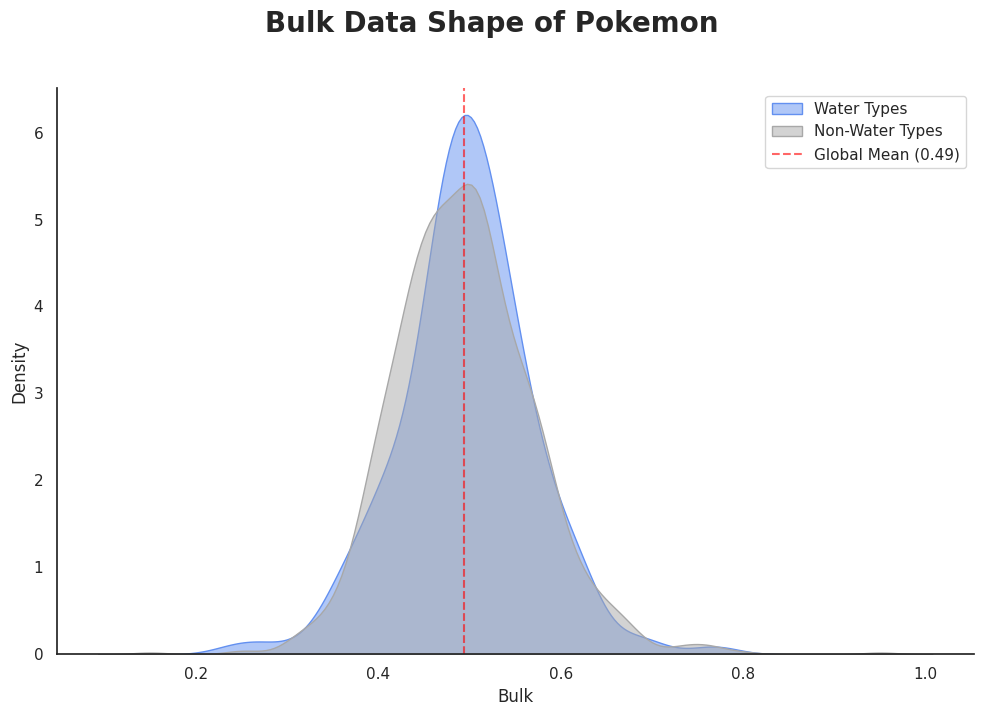

In [7]:
sns.set_theme(style="white")

# 1. Setup the figure
plt.figure(figsize=(10, 7))

# Define colors: Water Blue vs a Neutral Gray for others
palette = {True: "#6390F0", False: "#A8A8A8"}
labels = {True: "Water Types", False: "Non-Water Types"}

# --- Plot 1: KDE Distribution (The "Overlap" View) ---
for is_water in [True, False]:
    subset = df_bulk[df_bulk['is_water'] == is_water]
    sns.kdeplot(subset['bulk'], fill=True,
                color=palette[is_water], label=labels[is_water], alpha=0.5)


global_mean = df_bulk['bulk'].mean()
plt.axvline(global_mean, color='red', linestyle='--', alpha=0.6, label=f'Global Mean ({global_mean:.2f})')

plt.xlabel("Bulk")
plt.legend()

plt.suptitle("Bulk Data Shape of Pokemon", fontsize=20, y=1.02, fontweight="bold")
plt.tight_layout()
sns.despine() # Remove top and right spines
plt.show()

This visualization shows that the bulk data of Pokémon seems to be normaly distributed and visually there isn't much evidence to support my claim.

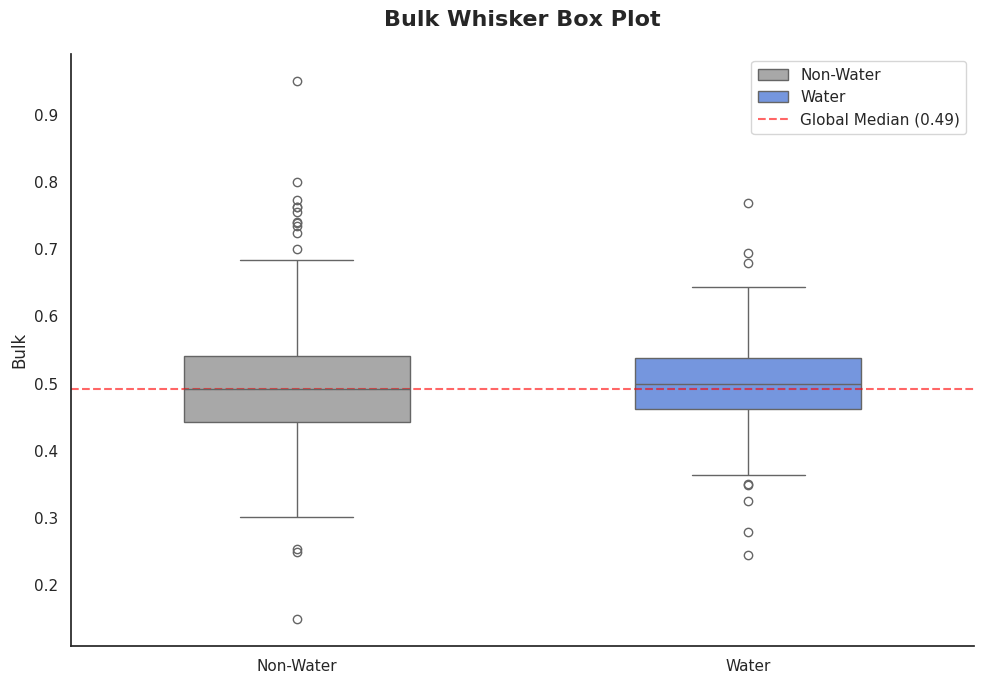

In [8]:
# 1. Prepare data (mapping booleans to strings to avoid palette errors)
plot_df = df_bulk.copy()
plot_df['Type Category'] = plot_df['is_water'].map({True: 'Water', False: 'Non-Water'})

# 2. Define colors
palette = {'Water': "#6390F0", 'Non-Water': "#A8A8A8"}

# 3. Setup the plot
plt.figure(figsize=(10, 7))

# Create the box plot
sns.boxplot(
    data=plot_df,
    x='Type Category',
    y='bulk',
    palette=palette,
    width=0.5,
    hue='Type Category',
    legend=True
)

global_median = df_bulk['bulk'].median()
plt.axhline(global_median, color='red', linestyle='--', alpha=0.6, label=f'Global Median ({global_median:.2f})')

# Formatting
plt.title("Bulk Whisker Box Plot", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Bulk", fontsize=12)
plt.xlabel("")
plt.legend(loc='upper right')

sns.despine() # Makes it look modern
plt.tight_layout()
plt.show()

To take a better look at how the data is spread, I drew a whisker box plot. Again my claim is visually unsupported. There are significantly more outliers in the Non-water category because the category is significantly more crowded.

In [9]:
water_bulk = df_bulk[df_bulk['is_water'] == True]['bulk']
non_water_bulk = df_bulk[df_bulk['is_water'] == False]['bulk']

print(f"Water types bulk variance: {water_bulk.var():.4f}")
print(f"Non-water types bulk variance: {non_water_bulk.var():.4f}")
# Checking the variance of each group to decide on the equal_var= parameter of ttest_ind

Water types bulk variance: 0.0053
Non-water types bulk variance: 0.0059


In [11]:
# One-sided T-Test (Alternative: Water > Non-Water)
# T-Test is chosen because I am comparing the means of two populations and my data is close to normally distributed
t_stat, p_val_t = stats.ttest_ind(water_bulk, non_water_bulk, alternative='greater')

print(f"T-test P-value: {p_val_t:.4f}")
if(p_val_t < 0.05):
  print(f"Null hypothesis rejected, water types are bulkier")
else:
  print(f"Failed to reject null hypothesis, water types do not have a statistically significant bulk advantage")

T-test P-value: 0.3412
Failed to reject null hypothesis, water types do not have a statistically significant bulk advantage


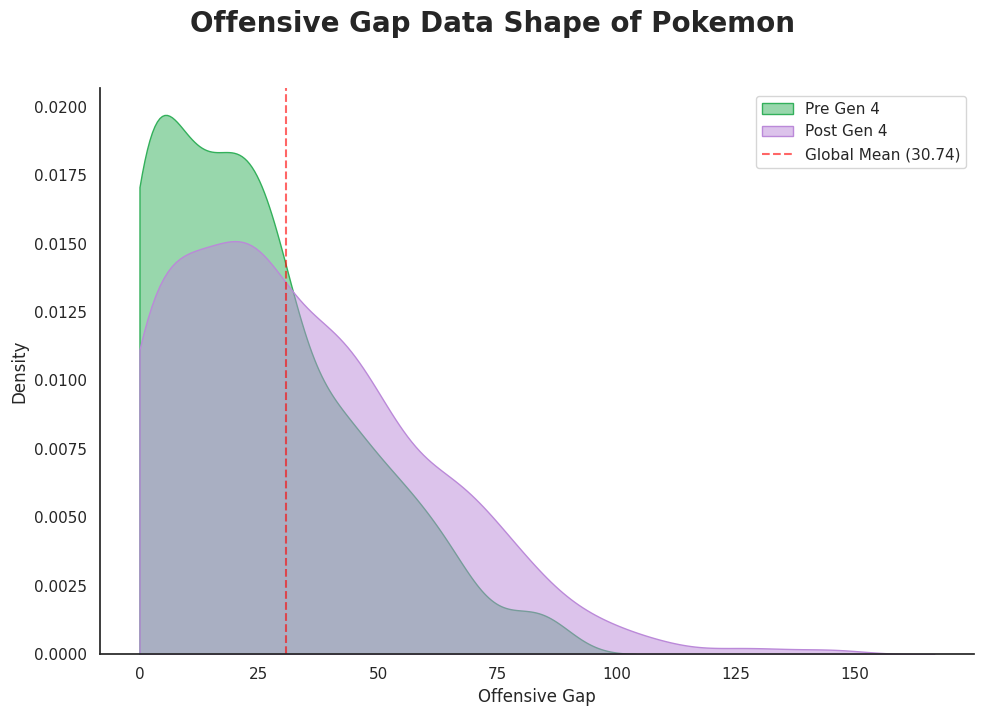

In [42]:
sns.set_theme(style="white")

# 1. Setup the figure
plt.figure(figsize=(10, 7))

palette = {True: "#33b05b", False: "#bb89d9"}
labels = {True: "Pre Gen 4", False: "Post Gen 4"}

# --- Plot 1: KDE Distribution (The "Overlap" View) ---
for pre_gen4 in [True, False]:
    subset = df_off_gap[df_off_gap['pre_gen4'] == pre_gen4]
    sns.kdeplot(subset['off_gap'], fill=True,
                color=palette[pre_gen4], label=labels[pre_gen4], alpha=0.5, clip=(0,None))


global_mean = df_off_gap['off_gap'].mean()
plt.axvline(global_mean, color='red', linestyle='--', alpha=0.6, label=f'Global Mean ({global_mean:.2f})')

plt.xlabel("Offensive Gap")
plt.legend()

plt.suptitle("Offensive Gap Data Shape of Pokemon", fontsize=20, y=1.02, fontweight="bold")
plt.tight_layout()
sns.despine() # Remove top and right spines
plt.show()

Question :Was there a design shift after the physical/special split of generation 4?

Offensive gap: The absolute value of the difference between a Pokémon's Attack and Special Attack stats

Hypothesis 2: The offensive gap of a Pokémon is higher after generation 4 (including generation 4) due to the physical/special split


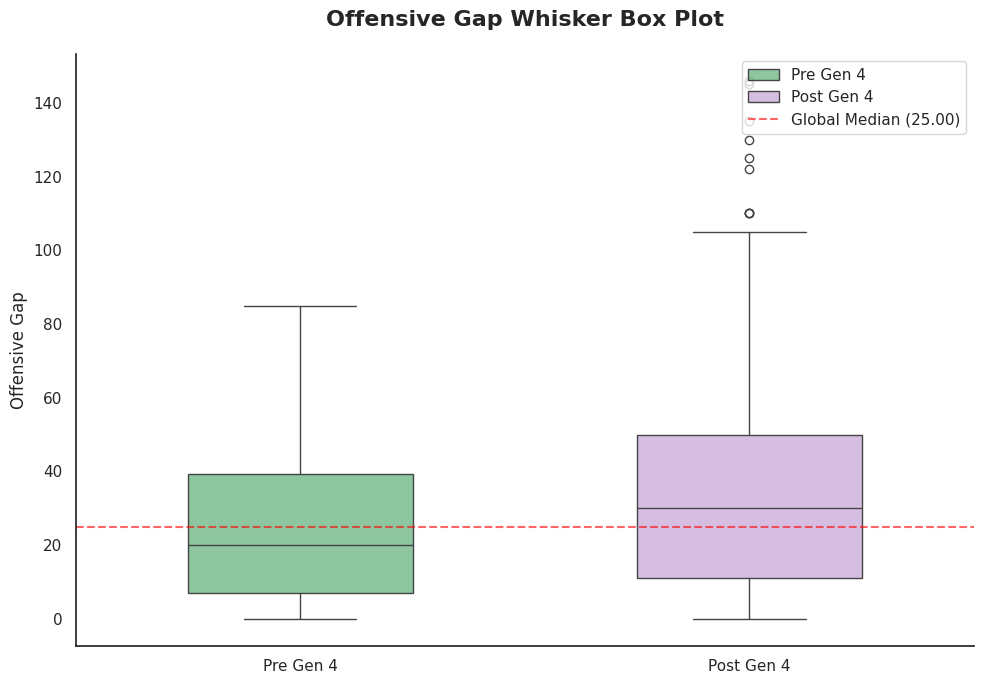

In [46]:
# 1. Prepare data (mapping booleans to strings to avoid palette errors)
plot_df = df_off_gap.copy()
plot_df['Type Category'] = plot_df['pre_gen4'].map({True: 'Pre Gen 4', False: 'Post Gen 4'})

# 2. Define colors
palette = {'Pre Gen 4': "#33b05b", 'Post Gen 4': "#bb89d9"}

# 3. Setup the plot
plt.figure(figsize=(10, 7))

# Create the box plot
ax = sns.boxplot(
    data=plot_df,
    x='Type Category',
    y='off_gap',
    palette=palette,
    width=0.5,
    hue='Type Category',
    legend=True
)

for patch in ax.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.6)) # Set alpha to 0.6

global_median = df_off_gap['off_gap'].median()
plt.axhline(global_median, color='red', linestyle='--', alpha=0.6, label=f'Global Median ({global_median:.2f})')

# Formatting
plt.title("Offensive Gap Whisker Box Plot", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Offensive Gap", fontsize=12)
plt.xlabel("")
plt.legend(loc='upper right')

sns.despine() # Makes it look modern
plt.tight_layout()
plt.show()

The visualizations seem to support my claim

In [38]:
pre_gen4_off_gap = df_off_gap[df_off_gap['pre_gen4'] == True]['off_gap']
post_gen4_off_gap = df_off_gap[df_off_gap['pre_gen4'] == False]['off_gap']

print(f"Pre gen 4 offensive gap variance: {pre_gen4_off_gap.var():.4f}")
print(f"Post gen 4 offensive gap variance: {post_gen4_off_gap.var():.4f}")
# Checking the variance of each group to decide on the equal_var= parameter of ttest_ind

Pre gen 4 offensive gap variance: 437.7588
Post gen 4 offensive gap variance: 702.5510


Both Welch's T-Test and Mann-Whitney U Test is performed to be sure, the data is distributed as a bell curve however it is right skewed. The variation is also high between the two populations

In [39]:
# One-sided Welch's T-Test (Alternative: pre gen 4 < post gen 4)
t_stat, p_val_t = stats.ttest_ind(pre_gen4_off_gap, post_gen4_off_gap, equal_var=False, alternative='less')

print(f"T-test P-value: {p_val_t:.12f}")
if(p_val_t < 0.05):
  print(f"Null hypothesis rejected, offensive gap post gen 4 is larger")
else:
  print(f"Failed to reject null hypothesis, there is not a statistically significant difference between pre and post generation 4 offensive gaps")

T-test P-value: 0.000000000008
Null hypothesis rejected, offensive gap post gen 4 is larger


In [40]:
# Mann-Whitney U (Alternative: pre gen 4 < post gen 4)
u_stat, p_val_u = stats.mannwhitneyu(pre_gen4_off_gap, post_gen4_off_gap, alternative='less')

print(f"Mann-Whitney U test P-value: {p_val_u:.12f}")
if(p_val_u < 0.05):
  print(f"Null hypothesis rejected, offensive gap post gen 4 is larger")
else:
  print(f"Failed to reject null hypothesis, there is not a statistically significant difference between pre and post generation 4 offensive gaps")

Mann-Whitney U test P-value: 0.000000003544
Null hypothesis rejected, offensive gap post gen 4 is larger


Quesiton: Is there signifcant powercreep in generation 9?

Hypothesis: Pokémon from generation 9 have a higher base stat total on average


In [12]:
excluded_forms = ['-gmax', '-mega', '-primal']

rows = []
for name, details in pokemon.items():
    skip = False
    for keyword in excluded_forms:
      if(keyword in name):
        skip = True
        break
    if(not skip):
      stats_dict = {s['stat']['name']: s['base_stat'] for s in details['stats']}

      # Calculate BST
      bst = sum(stats_dict.values())

      if(details['generation'] == 9):
        gen_9 = True
      else:
        gen_9 = False

      rows.append({'name': name, 'bst': bst, 'from_gen_9': gen_9})

df_powercreep_bst = pd.DataFrame(rows)
print(df_powercreep_bst)

                          name  bst  from_gen_9
0                    bulbasaur  318       False
1                      ivysaur  405       False
2                     venusaur  525       False
3                   charmander  309       False
4                   charmeleon  405       False
...                        ...  ...         ...
1148   ogerpon-wellspring-mask  550        True
1149  ogerpon-hearthflame-mask  550        True
1150  ogerpon-cornerstone-mask  550        True
1151        terapagos-terastal  600        True
1152         terapagos-stellar  700        True

[1153 rows x 3 columns]


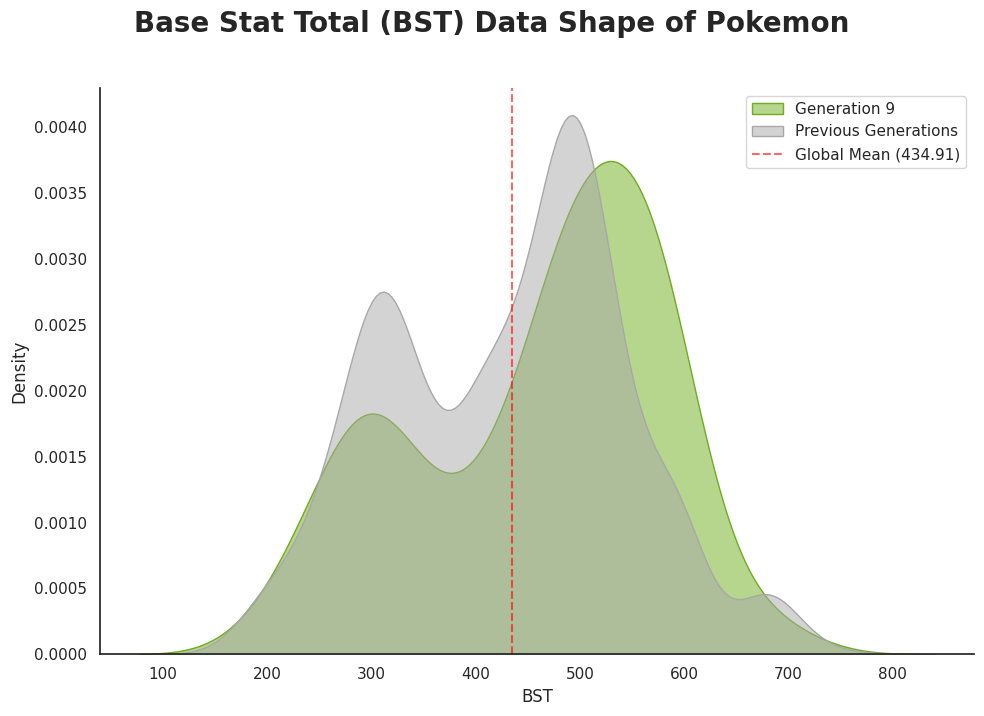

In [13]:
sns.set_theme(style="white")

# 1. Setup the figure
plt.figure(figsize=(10, 7))

# Define colors: gen 9 green vs a neutral grey for others
palette = {True: "#6ead1c", False: "#A8A8A8"}
labels = {True: "Generation 9", False: "Previous Generations"}

# --- Plot 1: KDE Distribution (The "Overlap" View) ---
for gen_9 in [True, False]:
    subset = df_powercreep_bst[df_powercreep_bst['from_gen_9'] == gen_9]
    sns.kdeplot(subset['bst'], fill=True,
                color=palette[gen_9], label=labels[gen_9], alpha=0.5)


global_mean = df_powercreep_bst['bst'].mean()
plt.axvline(global_mean, color='red', linestyle='--', alpha=0.6, label=f'Global Mean ({global_mean:.2f})')

plt.xlabel("BST")
plt.legend()

plt.suptitle("Base Stat Total (BST) Data Shape of Pokemon", fontsize=20, y=1.02, fontweight="bold")
plt.tight_layout()
sns.despine() # Remove top and right spines
plt.show()

The data is not normally distributed. There are two peaks the first likely are non-evolved Pokémon, it is expected that they will have a lower base stat total then their evolved counterparts. The second peak are fully evolved Pokémon. My claim is visually supported as the green distribution is slighty to the right of the grey one.

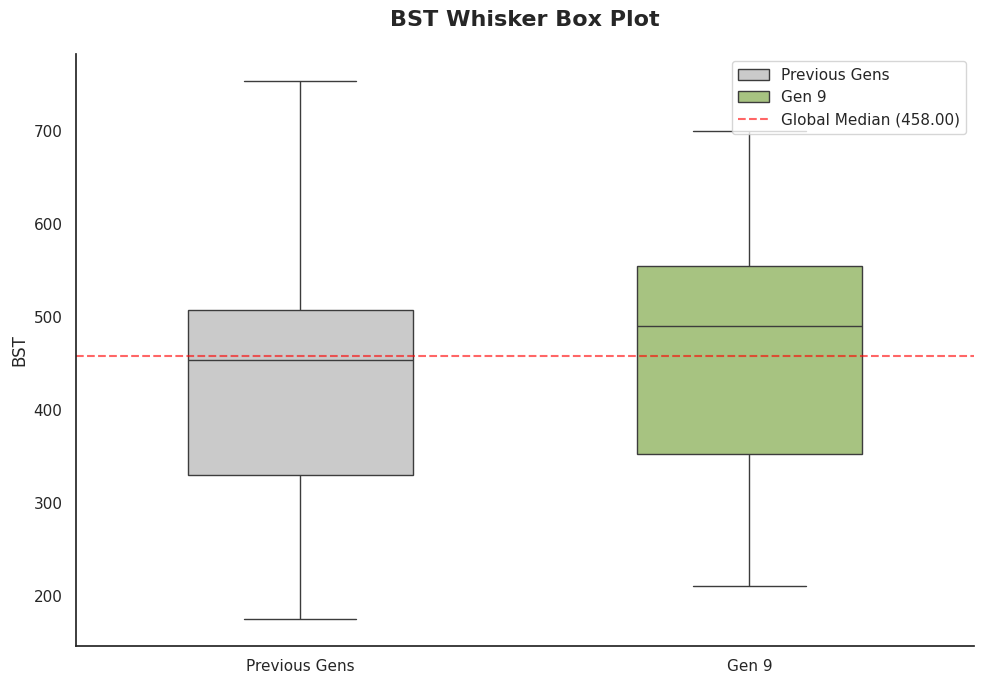

In [14]:
# 1. Prepare data (mapping booleans to strings to avoid palette errors)
plot_df = df_powercreep_bst.copy()
plot_df['Type Category'] = plot_df['from_gen_9'].map({True: 'Gen 9', False: 'Previous Gens'})

# 2. Define colors
palette = {'Gen 9': "#6ead1c", 'Previous Gens': "#A8A8A8"}

# 3. Setup the plot
plt.figure(figsize=(10, 7))

# Create the box plot
ax = sns.boxplot(
    data=plot_df,
    x='Type Category',
    y='bst',
    palette=palette,
    width=0.5,
    hue='Type Category',
    legend=True,
)

for patch in ax.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.6)) # Set alpha to 0.6

global_median = plot_df['bst'].median()
plt.axhline(global_median, color='red', linestyle='--', alpha=0.6, label=f'Global Median ({global_median:.2f})')

# Formatting
plt.title("BST Whisker Box Plot", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("BST", fontsize=12)
plt.xlabel("")
plt.legend(loc='upper right')

sns.despine() # Makes it look modern
plt.tight_layout()
plt.show()

Again, my claim is visually supported.

In [15]:
gen_9 = df_powercreep_bst[df_powercreep_bst['from_gen_9'] == True]['bst']
non_gen_9 = df_powercreep_bst[df_powercreep_bst['from_gen_9'] == False]['bst']

print(f"Gen 9 BST variance: {gen_9.var():.4f}")
print(f"Non gen 9 BST variance: {non_gen_9.var():.4f}")
# Checking the variance of each group to decide on the equal_var= parameter of ttest_ind

Gen 9 BST variance: 13833.0164
Non gen 9 BST variance: 13039.9250


Mann-Whitney U test is chosen because my data isn't normally disritibuted which is one of the assumptions of T-test

In [16]:
# Mann-Whitney U (Alternative: Gen_9 > Previous Gens)
u_stat, p_val_u = stats.mannwhitneyu(gen_9, non_gen_9, alternative='greater')

print(f"Mann-Whitney U test P-value: {p_val_u:.4f}")
if(p_val_u < 0.05):
  print(f"Null hypothesis rejected, generation 9 pokemon have a higher base stat total in general")
else:
  print(f"Failed to reject null hypothesis, generation 9 pokemon do not have a statistically significant base stat total advantage")

Mann-Whitney U test P-value: 0.0006
Null hypothesis rejected, generation 9 pokemon have a higher base stat total in general
